# Kindle Store Dataset Visualisation

This notebook visualises the Amazon Reviews 2023 `Kindle_Store` dataset for the COMP9727 recommender-system project.

The notebook is stored in `proj2`, but it reads the dataset from `../proj1` to avoid copying multi-GB files. It caches compact summary files under `proj2/cache` after the first full scan.

In [1]:
from pathlib import Path
import gzip
import json
from collections import Counter
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

PROJ2 = Path.cwd()
PROJ1 = PROJ2.parent / 'proj1'
REVIEW_PATH = PROJ1 / 'Kindle_Store.jsonl.gz'
META_PATH = PROJ1 / 'meta_Kindle_Store.jsonl.gz'
CACHE_DIR = PROJ2 / 'cache'
CACHE_DIR.mkdir(exist_ok=True)

print('Review file:', REVIEW_PATH, REVIEW_PATH.exists())
print('Metadata file:', META_PATH, META_PATH.exists())

Review file: d:\unsw\COMP9727\proj1\Kindle_Store.jsonl.gz True
Metadata file: d:\unsw\COMP9727\proj1\meta_Kindle_Store.jsonl.gz True


## Optional speed control

For final numbers, keep `MAX_REVIEW_LINES = None` and `MAX_META_LINES = None`. For a quick test run, set them to smaller values such as `500_000`.

In [2]:
MAX_REVIEW_LINES = None   # e.g. 500_000 for quick testing
MAX_META_LINES = None     # e.g. 200_000 for quick testing

## Review-data summary

This cell streams the review file once and caches compact aggregate statistics. It does not load the full JSONL into memory as a dataframe.

In [3]:
def scan_reviews(path=REVIEW_PATH, max_lines=MAX_REVIEW_LINES, cache_dir=CACHE_DIR):
    suffix = 'full' if max_lines is None else f'sample_{max_lines}'
    cache_path = cache_dir / f'kindle_review_summary_{suffix}.json'
    if cache_path.exists():
        with cache_path.open('r', encoding='utf-8') as f:
            return json.load(f)

    rating_counts = Counter()
    year_counts = Counter()
    user_counts = Counter()
    item_counts = Counter()
    verified_counts = Counter()
    bad_json = 0
    missing_required = 0
    min_ts = None
    max_ts = None
    total = 0

    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for line_no, line in enumerate(f, 1):
            if max_lines is not None and line_no > max_lines:
                break
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                bad_json += 1
                continue

            user_id = row.get('user_id')
            item_id = row.get('parent_asin')
            rating = row.get('rating')
            timestamp = row.get('timestamp')
            if user_id is None or item_id is None or rating is None or timestamp is None:
                missing_required += 1
                continue

            total += 1
            rating = float(rating)
            ts = int(timestamp)
            rating_counts[str(rating)] += 1
            user_counts[user_id] += 1
            item_counts[item_id] += 1
            verified_counts[str(row.get('verified_purchase'))] += 1
            year_counts[str(datetime.fromtimestamp(ts / 1000, tz=timezone.utc).year)] += 1
            min_ts = ts if min_ts is None else min(min_ts, ts)
            max_ts = ts if max_ts is None else max(max_ts, ts)

            if line_no % 2_000_000 == 0:
                print(f'scanned {line_no:,} lines...')

    user_values = np.array(list(user_counts.values()), dtype=np.int64)
    item_values = np.array(list(item_counts.values()), dtype=np.int64)
    bins = [1, 2, 3, 5, 10, 20, 50, 100, 200, 500, 1000, 10_000]

    def survival_counts(values):
        return {str(b): int((values >= b).sum()) for b in bins}

    summary = {
        'total_interactions': int(total),
        'num_users': int(len(user_counts)),
        'num_items': int(len(item_counts)),
        'rating_counts': dict(rating_counts),
        'verified_counts': dict(verified_counts),
        'year_counts': dict(year_counts),
        'bad_json': bad_json,
        'missing_required': missing_required,
        'min_date': str(datetime.fromtimestamp(min_ts / 1000, tz=timezone.utc).date()) if min_ts else None,
        'max_date': str(datetime.fromtimestamp(max_ts / 1000, tz=timezone.utc).date()) if max_ts else None,
        'avg_interactions_per_user': float(total / len(user_counts)) if user_counts else 0.0,
        'median_interactions_per_user': float(np.median(user_values)) if len(user_values) else 0.0,
        'avg_interactions_per_item': float(total / len(item_counts)) if item_counts else 0.0,
        'median_interactions_per_item': float(np.median(item_values)) if len(item_values) else 0.0,
        'users_ge_threshold': survival_counts(user_values),
        'items_ge_threshold': survival_counts(item_values),
        'positive_ge_4': int(sum(v for k, v in rating_counts.items() if float(k) >= 4)),
    }
    summary['positive_ge_4_rate'] = summary['positive_ge_4'] / total if total else 0.0

    with cache_path.open('w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)
    return summary

review_summary = scan_reviews()
review_summary

scanned 2,000,000 lines...
scanned 4,000,000 lines...
scanned 6,000,000 lines...
scanned 8,000,000 lines...
scanned 10,000,000 lines...
scanned 12,000,000 lines...
scanned 14,000,000 lines...
scanned 16,000,000 lines...
scanned 18,000,000 lines...
scanned 20,000,000 lines...
scanned 22,000,000 lines...
scanned 24,000,000 lines...


{'total_interactions': 25577616,
 'num_users': 5646991,
 'num_items': 1590697,
 'rating_counts': {'5.0': 16699504,
  '3.0': 1940802,
  '4.0': 5386277,
  '1.0': 738729,
  '2.0': 812301,
  '0.0': 3},
 'verified_counts': {'False': 8193631, 'True': 17383985},
 'year_counts': {'2015': 2819569,
  '2017': 2729707,
  '2022': 1891488,
  '2013': 1942498,
  '2021': 2024915,
  '2020': 2170734,
  '2019': 2263300,
  '2018': 2463305,
  '2016': 2852713,
  '2014': 2967159,
  '2023': 696419,
  '2012': 590633,
  '2011': 124492,
  '2010': 29923,
  '2006': 29,
  '2009': 8042,
  '2008': 2499,
  '2007': 157,
  '2005': 10,
  '2001': 7,
  '2004': 7,
  '1999': 1,
  '2002': 3,
  '2000': 5,
  '2003': 1},
 'bad_json': 0,
 'missing_required': 0,
 'min_date': '1999-08-28',
 'max_date': '2023-09-13',
 'avg_interactions_per_user': 4.529423900268302,
 'median_interactions_per_user': 1.0,
 'avg_interactions_per_item': 16.07950225592932,
 'median_interactions_per_item': 3.0,
 'users_ge_threshold': {'1': 5646991,
  '2': 2

## Dataset overview

In [4]:
overview = pd.DataFrame([
    ['Interactions', review_summary['total_interactions']],
    ['Users', review_summary['num_users']],
    ['Items', review_summary['num_items']],
    ['Avg interactions/user', review_summary['avg_interactions_per_user']],
    ['Median interactions/user', review_summary['median_interactions_per_user']],
    ['Positive rating >=4 rate', review_summary['positive_ge_4_rate']],
], columns=['Metric', 'Value'])
overview

,Metric,Value
0,Interactions,2.557762e+07
1,Users,5.646991e+06
2,Items,1.590697e+06
3,Avg interactions/user,4.529424e+00
4,Median interactions/user,1.000000e+00
5,Positive rating >=4 rate,8.634808e-01


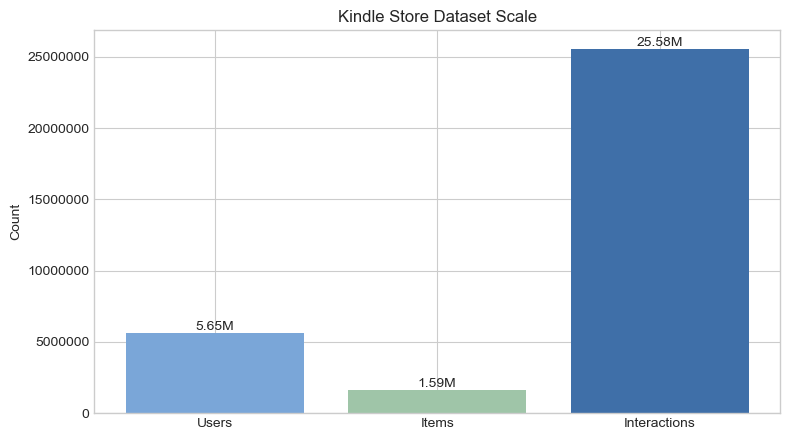

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
metrics = ['Users', 'Items', 'Interactions']
values = [review_summary['num_users'], review_summary['num_items'], review_summary['total_interactions']]
ax.bar(metrics, values, color=['#7aa6d8', '#9fc5a8', '#3f6fa8'])
ax.set_title('Kindle Store Dataset Scale')
ax.set_ylabel('Count')
ax.ticklabel_format(style='plain', axis='y')
for i, v in enumerate(values):
    ax.text(i, v, f'{v/1e6:.2f}M', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Rating distribution

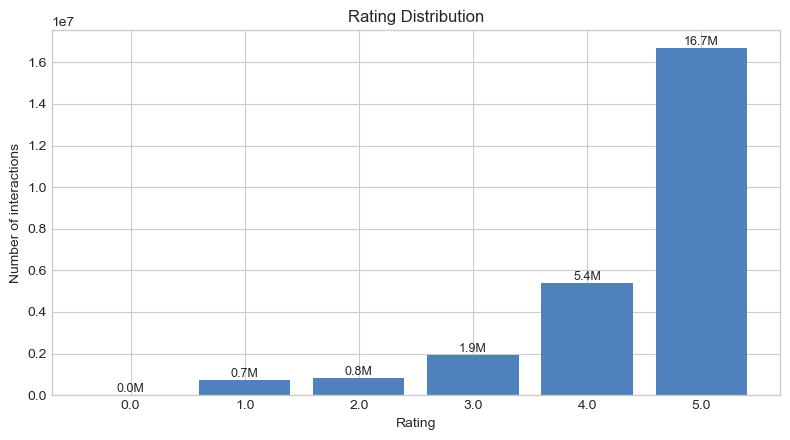

In [6]:
rating_df = pd.DataFrame(
    sorted((float(k), v) for k, v in review_summary['rating_counts'].items()),
    columns=['rating', 'count']
)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(rating_df['rating'].astype(str), rating_df['count'], color='#4f81bd')
ax.set_title('Rating Distribution')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of interactions')
for i, v in enumerate(rating_df['count']):
    ax.text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## User and item sparsity

These plots show how many users/items remain after minimum-interaction thresholds. They support the proposed filtering strategy for sequential modelling.

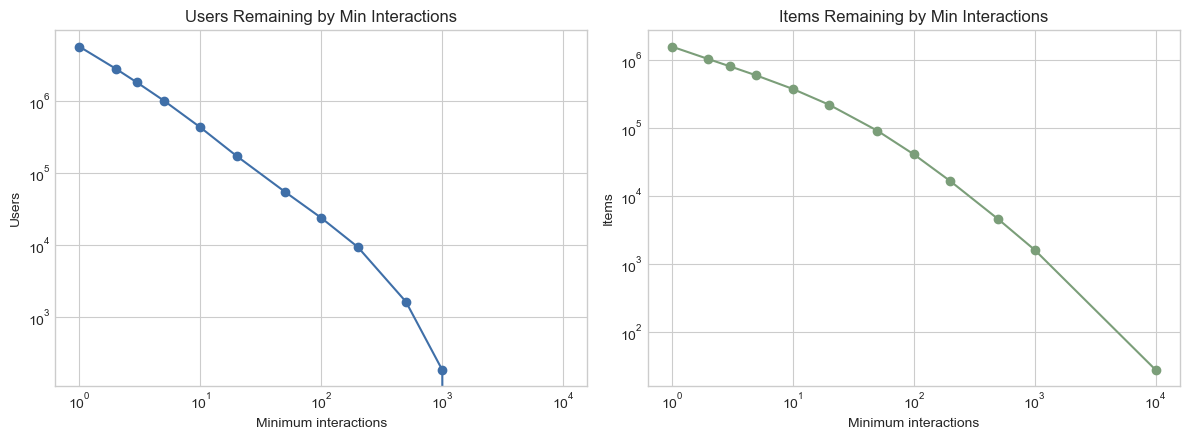

In [7]:
users_thr = pd.DataFrame({
    'threshold': [int(k) for k in review_summary['users_ge_threshold'].keys()],
    'users': list(review_summary['users_ge_threshold'].values())
}).sort_values('threshold')
items_thr = pd.DataFrame({
    'threshold': [int(k) for k in review_summary['items_ge_threshold'].keys()],
    'items': list(review_summary['items_ge_threshold'].values())
}).sort_values('threshold')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(users_thr['threshold'], users_thr['users'], marker='o', color='#3f6fa8')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Users Remaining by Min Interactions')
axes[0].set_xlabel('Minimum interactions')
axes[0].set_ylabel('Users')

axes[1].plot(items_thr['threshold'], items_thr['items'], marker='o', color='#7b9e79')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Items Remaining by Min Interactions')
axes[1].set_xlabel('Minimum interactions')
axes[1].set_ylabel('Items')
plt.tight_layout()
plt.show()

## Interactions over time

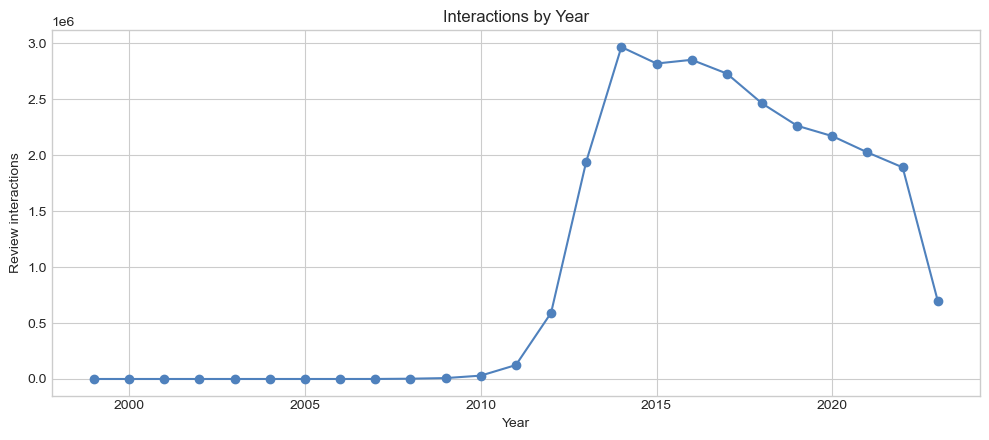

In [8]:
year_df = pd.DataFrame(
    sorted((int(k), v) for k, v in review_summary['year_counts'].items()),
    columns=['year', 'count']
)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(year_df['year'], year_df['count'], marker='o', color='#4f81bd')
ax.set_title('Interactions by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Review interactions')
plt.tight_layout()
plt.show()

## Comparison with other Amazon subsets

These values are from the project comparison statistics and motivate choosing Kindle Store.

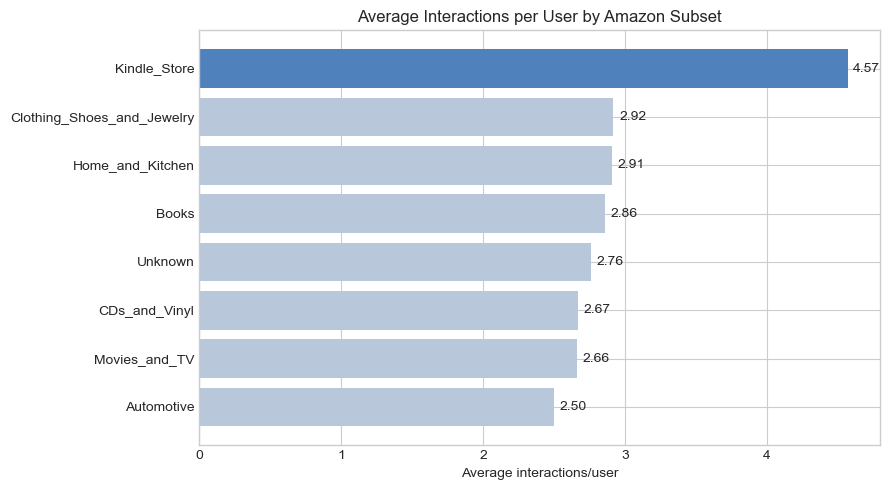

In [9]:
category_avg = pd.DataFrame({
    'category': [
        'Kindle_Store', 'Clothing_Shoes_and_Jewelry', 'Home_and_Kitchen', 'Books',
        'Unknown', 'CDs_and_Vinyl', 'Movies_and_TV', 'Automotive'
    ],
    'avg_interactions_per_user': [4.57, 2.92, 2.91, 2.86, 2.76, 2.67, 2.66, 2.50]
}).sort_values('avg_interactions_per_user')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#4f81bd' if c == 'Kindle_Store' else '#b8c7d9' for c in category_avg['category']]
ax.barh(category_avg['category'], category_avg['avg_interactions_per_user'], color=colors)
ax.set_title('Average Interactions per User by Amazon Subset')
ax.set_xlabel('Average interactions/user')
for y, v in enumerate(category_avg['avg_interactions_per_user']):
    ax.text(v + 0.04, y, f'{v:.2f}', va='center')
plt.tight_layout()
plt.show()

## Metadata category and missingness summary

This scan uses `meta_Kindle_Store.jsonl.gz`. It may take a few minutes on the full metadata file.

In [10]:
def scan_metadata(path=META_PATH, max_lines=MAX_META_LINES, cache_dir=CACHE_DIR):
    suffix = 'full' if max_lines is None else f'sample_{max_lines}'
    cache_path = cache_dir / f'kindle_meta_summary_{suffix}.json'
    if cache_path.exists():
        with cache_path.open('r', encoding='utf-8') as f:
            return json.load(f)

    fields = ['title', 'categories', 'description', 'details', 'features', 'author', 'average_rating', 'rating_number', 'images']
    missing = Counter()
    categories = Counter()
    total = 0
    bad_json = 0

    with gzip.open(path, 'rt', encoding='utf-8') as f:
        for line_no, line in enumerate(f, 1):
            if max_lines is not None and line_no > max_lines:
                break
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                bad_json += 1
                continue
            total += 1
            for field in fields:
                value = row.get(field)
                if value in (None, '', [], {}):
                    missing[field] += 1
            cats = row.get('categories') or []
            if cats:
                categories[' > '.join(map(str, cats[:3]))] += 1
            if line_no % 1_000_000 == 0:
                print(f'scanned {line_no:,} metadata lines...')

    summary = {
        'total_metadata_rows': total,
        'bad_json': bad_json,
        'missing': dict(missing),
        'top_categories': dict(categories.most_common(20)),
    }
    with cache_path.open('w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)
    return summary

meta_summary = scan_metadata()
meta_summary

scanned 1,000,000 metadata lines...


{'total_metadata_rows': 1591371,
 'bad_json': 0,
 'missing': {'description': 950868,
  'author': 335876,
  'features': 32158,
  'images': 424064,
  'details': 57603},
 'top_categories': {'Kindle Store > Kindle eBooks > Literature & Fiction': 498481,
  'Kindle Store > Kindle eBooks > Romance': 135539,
  'Kindle Store > Kindle eBooks > Religion & Spirituality': 123571,
  'Kindle Store > Kindle eBooks > Science Fiction & Fantasy': 106598,
  "Kindle Store > Kindle eBooks > Children's eBooks": 102704,
  'Kindle Store > Kindle eBooks > Mystery, Thriller & Suspense': 75220,
  'Kindle Store > Kindle eBooks > Business & Money': 67279,
  'Kindle Store > Kindle eBooks > History': 52728,
  'Kindle Store > Kindle eBooks > Teen & Young Adult': 49603,
  'Kindle Store > Kindle eBooks > Biographies & Memoirs': 45885,
  'Kindle Store > Kindle eBooks > Health, Fitness & Dieting': 33553,
  'Kindle Store > Kindle eBooks > Politics & Social Sciences': 28877,
  'Kindle Store > Kindle eBooks > Comics, Manga &

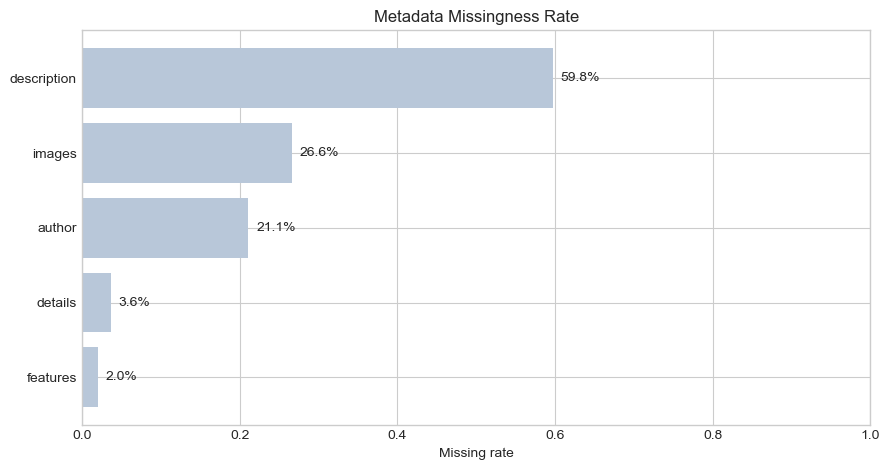

In [11]:
missing_df = pd.DataFrame({
    'field': list(meta_summary['missing'].keys()),
    'missing_count': list(meta_summary['missing'].values())
})
missing_df['missing_rate'] = missing_df['missing_count'] / meta_summary['total_metadata_rows']
missing_df = missing_df.sort_values('missing_rate')

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.barh(missing_df['field'], missing_df['missing_rate'], color='#b8c7d9')
ax.set_title('Metadata Missingness Rate')
ax.set_xlabel('Missing rate')
ax.set_xlim(0, 1)
for y, v in enumerate(missing_df['missing_rate']):
    ax.text(v + 0.01, y, f'{v:.1%}', va='center')
plt.tight_layout()
plt.show()

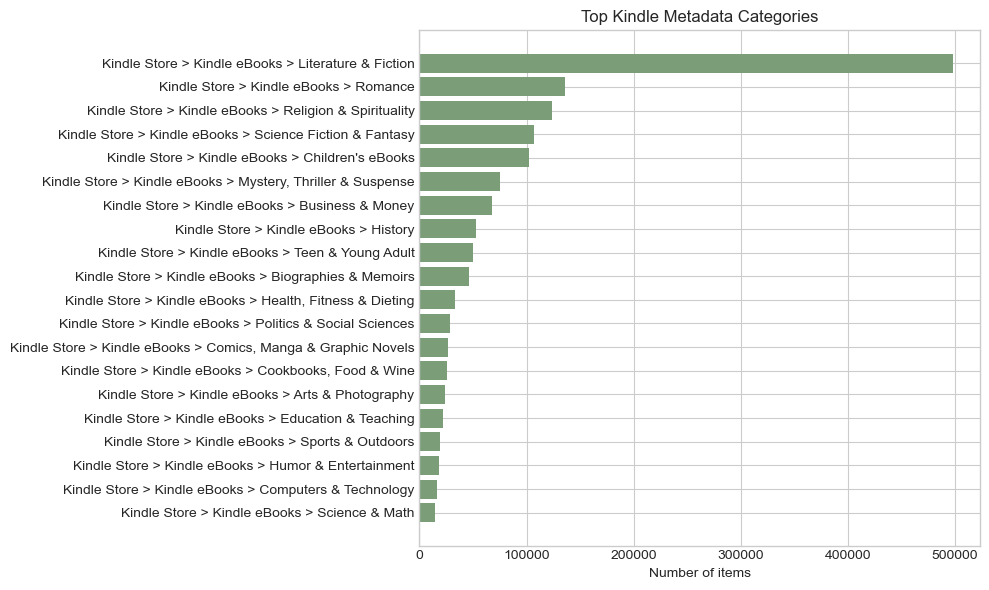

In [12]:
top_cat_df = pd.DataFrame(
    list(meta_summary['top_categories'].items()),
    columns=['category_path', 'count']
).sort_values('count')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_cat_df['category_path'], top_cat_df['count'], color='#7b9e79')
ax.set_title('Top Kindle Metadata Categories')
ax.set_xlabel('Number of items')
plt.tight_layout()
plt.show()

## Suggested figures for the report

Recommended figures to include in the final report:

1. Average interactions/user comparison across Amazon subsets.
2. Rating distribution for Kindle Store.
3. Users/items remaining after minimum-interaction thresholds.
4. Metadata missingness or top categories, if discussing content-based recommendation.